# Caso-taller: ¿Dónde abrir una nueva sede?

**Grupo 12 - MIID 4303, Aprendizaje no supervisado**

Una empresa quiere reducir 329 ciudades candidatas a cinco opciones para una fase de *due diligence*. Este cuaderno construye el filtro con los nueve criterios disponibles y muestra, en este orden, los datos, los patrones encontrados, el ranking y la recomendación.

La pregunta que guía el trabajo es:

> **¿Qué cinco ciudades muestran el perfil más atractivo y estable, y qué ventajas y riesgos tiene cada una?**

Los datos corresponden a 1985. Por eso los hallazgos no se presentan como una respuesta actual, sino como una forma reproducible de escoger dónde investigar primero.

### Recorrido

1. Conocer y revisar los datos.
2. Hacer comparables los nueve criterios.
3. Resumir los patrones con PCA.
4. Construir y visualizar el ranking.
5. Comprobar si cambia con otras decisiones.
6. Elegir cinco finalistas y explicar sus fortalezas y riesgos.

## 1. Reproducibilidad y librerías

El cuaderno usa exclusivamente la ruta relativa exigida: `data/lugares.csv`. Se fija una semilla aunque PCA con `svd_solver="full"` es determinista; así la entrega queda preparada para cualquier extensión aleatoria. Los resultados se escriben en `resultados/`, sin depender de rutas del autor.

In [1]:
from pathlib import Path
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

SEMILLA = 4303
random.seed(SEMILLA)
np.random.seed(SEMILLA)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

RUTA_DATOS = Path("data/lugares.csv")
RUTA_RESULTADOS = Path("resultados")
RUTA_RESULTADOS.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| numpy:", np.__version__, "| sklearn:", sklearn.__version__)
print("Semilla:", SEMILLA, "| Datos:", RUTA_DATOS)

Python: 3.13.9
pandas: 2.3.3 | numpy: 2.3.5 | sklearn: 1.7.2
Semilla: 4303 | Datos: data\lugares.csv


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\harol\\AppData\\Local\\Temp\\matplotlib-kp819l2q\\fontlist-v390.json.matplotlib-lock'


Python: 3.13.9
pandas: 2.3.3 | numpy: 2.3.5 | sklearn: 1.7.2
Semilla: 4303 | Datos: data\lugares.csv


## 2. Carga y controles de calidad

Se esperan 329 ciudades, un identificador y nueve criterios numéricos. Las aserciones detienen la ejecución si el archivo cambia, falta, contiene nulos o no conserva la estructura del caso; esto evita producir silenciosamente un ranking inválido.

In [2]:
assert RUTA_DATOS.exists(), f"No se encontró {RUTA_DATOS}. El cuaderno debe estar junto a la carpeta data/."
datos = pd.read_csv(RUTA_DATOS)
variables = datos.columns.drop("Ciudad").tolist()

assert datos.shape == (329, 10), f"Dimensión inesperada: {datos.shape}"
assert len(variables) == 9
assert datos[variables].apply(pd.api.types.is_numeric_dtype).all()
assert datos.isna().sum().sum() == 0

control = pd.Series({
    "filas": len(datos),
    "columnas": datos.shape[1],
    "criterios_numéricos": len(variables),
    "faltantes": int(datos.isna().sum().sum()),
    "filas_duplicadas": int(datos.duplicated().sum()),
    "ciudades_duplicadas": int(datos["Ciudad"].duplicated().sum()),
}, name="valor").to_frame()
display(control)
display(datos.head())

,valor
filas,329
columnas,10
criterios_numéricos,9
faltantes,0
filas_duplicadas,0
ciudades_duplicadas,0


,Ciudad,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
0,"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
1,"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
2,"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
3,"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
4,"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


### Dirección empresarial de los criterios

En siete criterios, mayor puntuación significa mejor evaluación. En **Alojamiento** y **Crimen**, menor puntuación es mejor. Para que una cifra positiva siempre signifique mayor atractivo, esos dos criterios se multiplican por -1 antes de estandarizar. Esta transformación solo invierte sus ejes: no altera distancias ni correlaciones absolutas, pero reduce el riesgo de interpretar al revés las cargas y el índice.

In [3]:
direccion = pd.DataFrame({
    "criterio": variables,
    "mejor_si": ["menor" if v in ["Alojamiento", "Crimen"] else "mayor" for v in variables],
    "transformación": ["multiplicar por -1" if v in ["Alojamiento", "Crimen"] else "sin cambio" for v in variables],
})
display(direccion)

,criterio,mejor_si,transformación
0,Clima y Terreno,mayor,sin cambio
1,Alojamiento,menor,multiplicar por -1
2,Cuidado de la salud y el medio ambiente,mayor,sin cambio
3,Crimen,menor,multiplicar por -1
4,Transporte,mayor,sin cambio
5,Educación,mayor,sin cambio
6,Artes,mayor,sin cambio
7,Recreación,mayor,sin cambio
8,Economía,mayor,sin cambio


## 3. Exploración de los datos

Con nueve criterios existen $9(9-1)/2=36$ relaciones por pares. Antes de reducir la dimensión se revisan escalas, dispersión, asociaciones y atípicos. No se elimina ninguna ciudad de forma automática: una observación extrema puede ser una ciudad grande con un perfil real y relevante para la decisión.

In [4]:
resumen = datos[variables].describe().T
resumen["rango"] = resumen["max"] - resumen["min"]
resumen["coef_variación"] = resumen["std"] / resumen["mean"]
resumen["varianza"] = datos[variables].var()

print("Relaciones por pares:", len(variables) * (len(variables) - 1) // 2)
print("Razón entre la mayor y la menor varianza original:", f"{resumen['varianza'].max()/resumen['varianza'].min():,.0f} veces")
display(resumen)

Relaciones por pares: 36
Razón entre la mayor y la menor varianza original: 1,477 veces


,count,mean,std,min,25%,50%,75%,max,rango,coef_variación,varianza
Clima y Terreno,329.000,538.733,120.808,105.000,480.000,542.000,592.000,910.000,805.000,0.224,"14,594.636"
Alojamiento,329.000,"8,346.559","2,385.263","5,159.000","6,760.000","7,877.000","9,015.000","23,640.000","18,481.000",0.286,"5,689,477.778"
Cuidado de la salud y el medio ambiente,329.000,"1,185.739","1,003.002",43.000,583.000,833.000,"1,445.000","7,850.000","7,807.000",0.846,"1,006,013.084"
Crimen,329.000,961.055,357.154,308.000,707.000,947.000,"1,156.000","2,498.000","2,190.000",0.372,"127,559.113"
Transporte,329.000,"4,210.082","1,451.179","1,145.000","3,141.000","4,080.000","5,205.000","8,625.000","7,480.000",0.345,"2,105,921.185"
Educación,329.000,"2,814.888",320.793,"1,701.000","2,619.000","2,794.000","3,012.000","3,781.000","2,080.000",0.114,"102,908.118"
Artes,329.000,"3,150.884","4,642.284",52.000,778.000,"1,871.000","3,844.000","56,745.000","56,693.000",1.473,"21,550,798.304"
Recreación,329.000,"1,845.957",807.888,300.000,"1,316.000","1,670.000","2,176.000","4,800.000","4,500.000",0.438,"652,683.297"
Economía,329.000,"5,525.365","1,084.469","3,045.000","4,842.000","5,384.000","6,113.000","9,980.000","6,935.000",0.196,"1,176,071.976"


,count,mean,std,min,25%,50%,75%,max,rango,coef_variación,varianza
Clima y Terreno,329.000,538.733,120.808,105.000,480.000,542.000,592.000,910.000,805.000,0.224,"14,594.636"
Alojamiento,329.000,"8,346.559","2,385.263","5,159.000","6,760.000","7,877.000","9,015.000","23,640.000","18,481.000",0.286,"5,689,477.778"
Cuidado de la salud y el medio ambiente,329.000,"1,185.739","1,003.002",43.000,583.000,833.000,"1,445.000","7,850.000","7,807.000",0.846,"1,006,013.084"
Crimen,329.000,961.055,357.154,308.000,707.000,947.000,"1,156.000","2,498.000","2,190.000",0.372,"127,559.113"
Transporte,329.000,"4,210.082","1,451.179","1,145.000","3,141.000","4,080.000","5,205.000","8,625.000","7,480.000",0.345,"2,105,921.185"
Educación,329.000,"2,814.888",320.793,"1,701.000","2,619.000","2,794.000","3,012.000","3,781.000","2,080.000",0.114,"102,908.118"
Artes,329.000,"3,150.884","4,642.284",52.000,778.000,"1,871.000","3,844.000","56,745.000","56,693.000",1.473,"21,550,798.304"
Recreación,329.000,"1,845.957",807.888,300.000,"1,316.000","1,670.000","2,176.000","4,800.000","4,500.000",0.438,"652,683.297"
Economía,329.000,"5,525.365","1,084.469","3,045.000","4,842.000","5,384.000","6,113.000","9,980.000","6,935.000",0.196,"1,176,071.976"


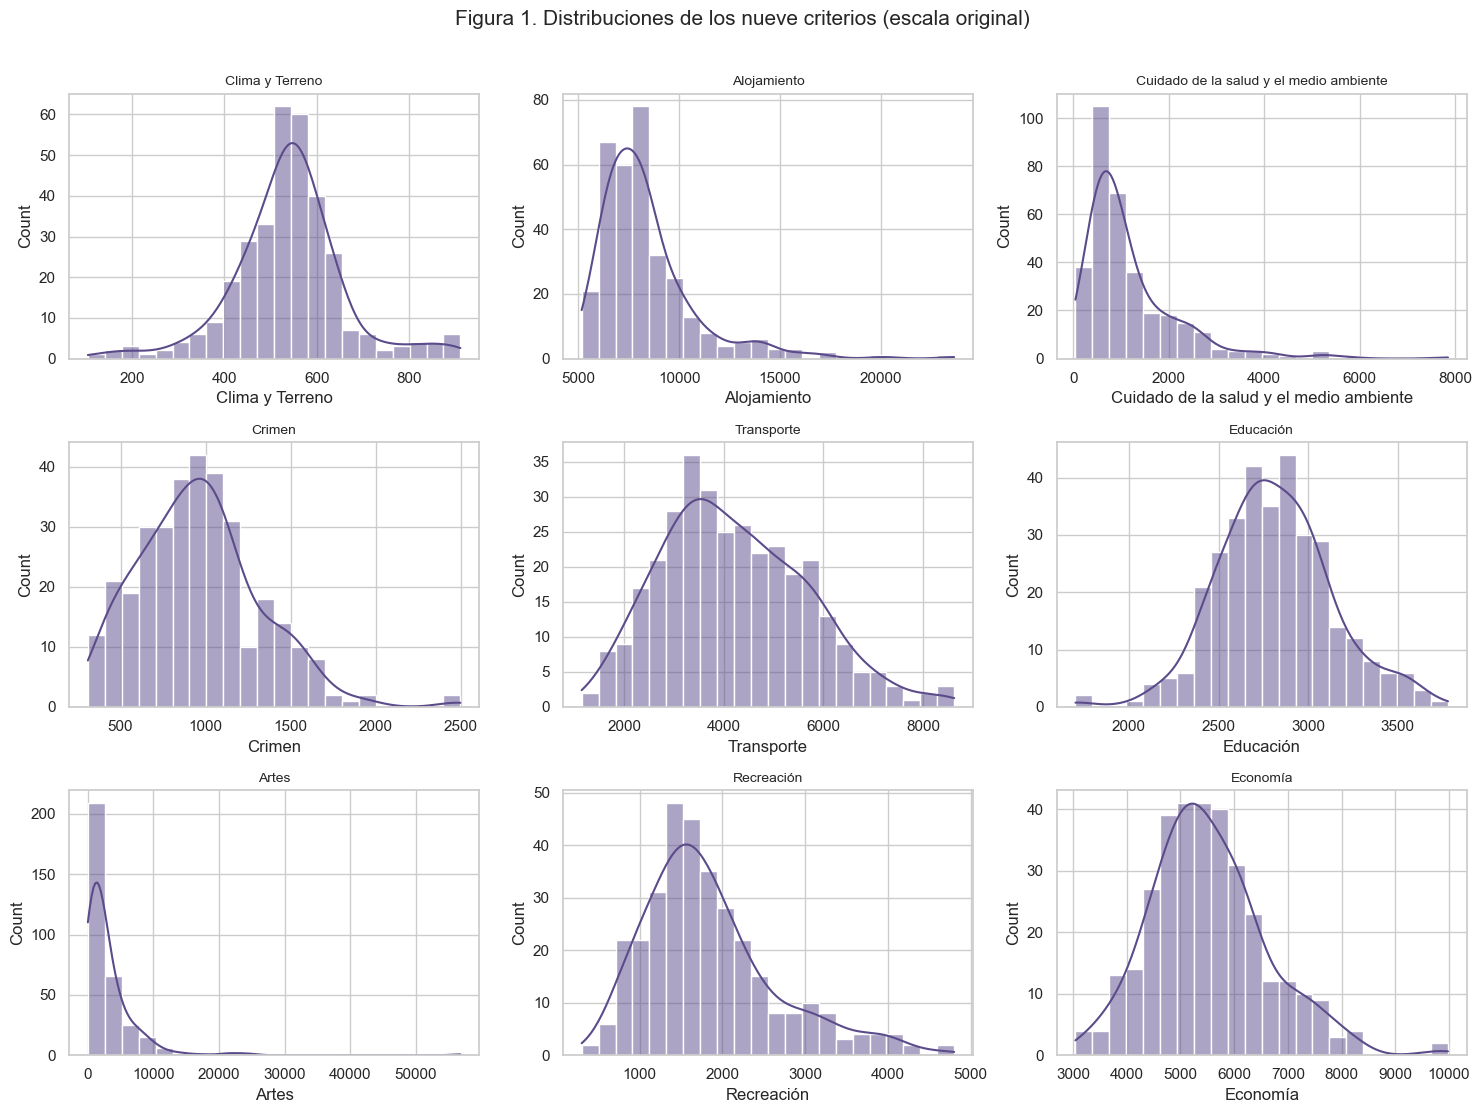

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, variable in zip(axes.flat, variables):
    sns.histplot(datos[variable], bins=22, kde=True, ax=ax, color="#5B4B8A")
    ax.set_title(variable, fontsize=10)
fig.suptitle("Figura 1. Distribuciones de los nueve criterios (escala original)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Hallazgo: las escalas no son comparables

Algunas columnas varían miles de veces más que otras. Si se usaran tal como vienen, las de números grandes dominarían el resultado. Estandarizar evita que la unidad de medida decida por nosotros y da a los nueve criterios el mismo punto de partida.

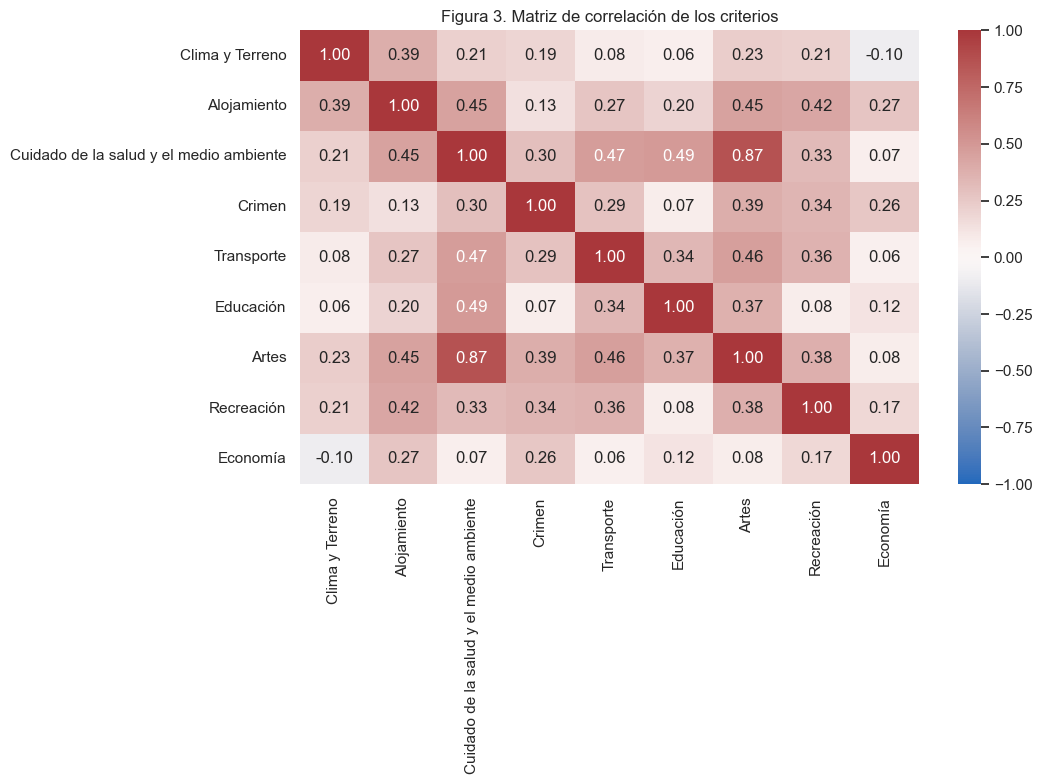

,criterio_1,criterio_2,correlación
18,Cuidado de la salud y el medio ambiente,Artes,0.866
17,Cuidado de la salud y el medio ambiente,Educación,0.490
16,Cuidado de la salud y el medio ambiente,Transporte,0.470
27,Transporte,Artes,0.465
8,Alojamiento,Cuidado de la salud y el medio ambiente,0.453
12,Alojamiento,Artes,0.449
13,Alojamiento,Recreación,0.422
23,Crimen,Artes,0.389
0,Clima y Terreno,Alojamiento,0.386
33,Artes,Recreación,0.379


In [6]:
corr = datos[variables].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Figura 3. Matriz de correlación de los criterios")
plt.tight_layout()
plt.show()

pares = []
for i, a in enumerate(variables):
    for b in variables[i+1:]:
        pares.append((a, b, corr.loc[a, b]))
correlaciones_fuertes = pd.DataFrame(pares, columns=["criterio_1", "criterio_2", "correlación"])
correlaciones_fuertes["abs_correlación"] = correlaciones_fuertes["correlación"].abs()
display(correlaciones_fuertes.nlargest(10, "abs_correlación").drop(columns="abs_correlación"))

### Hallazgo: los servicios urbanos aparecen juntos

Salud/medio ambiente y Artes tienen la relación más fuerte. Salud también se mueve con Educación y Transporte. En términos sencillos, las ciudades con más infraestructura suelen reunir varios servicios a la vez. Esto ayuda a explicar por qué algunos centros metropolitanos sobresalen, pero no demuestra que un criterio cause el otro.

In [7]:
def resumen_atipicos_iqr(df, columnas):
    filas, mascara_global = [], pd.Series(False, index=df.index)
    for col in columnas:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mascara = (df[col] < inferior) | (df[col] > superior)
        mascara_global |= mascara
        filas.append([col, int(mascara.sum()), inferior, superior])
    return pd.DataFrame(filas, columns=["criterio", "n_atípicos", "límite_inferior", "límite_superior"]), mascara_global

tabla_atipicos, es_atipica = resumen_atipicos_iqr(datos, variables)
display(tabla_atipicos)
print("Ciudades atípicas en al menos un criterio:", int(es_atipica.sum()))

X_orientado = datos[variables].copy()
X_orientado[["Alojamiento", "Crimen"]] *= -1
Z = pd.DataFrame(StandardScaler().fit_transform(X_orientado), columns=variables, index=datos.index)
datos_extremos = datos[["Ciudad"]].copy()
datos_extremos["máximo_abs_z"] = Z.abs().max(axis=1)
display(datos_extremos.nlargest(12, "máximo_abs_z"))

,criterio,n_atípicos,límite_inferior,límite_superior
0,Clima y Terreno,30,312.000,760.000
1,Alojamiento,22,"3,377.500","12,397.500"
2,Cuidado de la salud y el medio ambiente,20,-710.000,"2,738.000"
3,Crimen,5,33.500,"1,829.500"
4,Transporte,2,45.000,"8,301.000"
5,Educación,7,"2,029.500","3,601.500"
6,Artes,24,"-3,821.000","8,443.000"
7,Recreación,18,26.000,"3,466.000"
8,Economía,7,"2,935.500","8,019.500"


Ciudades atípicas en al menos un criterio: 81


,Ciudad,máximo_abs_z
212,"New-York,NY",11.562
289,"Stamford,CT",6.421
216,"Norwalk,CT",4.956
64,"Chicago,IL",4.680
178,"Los-Angeles,Long-Beach,CA",4.405
191,"Miami-Hialeah,FL",4.201
194,"Midland,TX",4.114
42,"Boston,MA",4.109
313,"Washington,DC-MD-VA",4.002
233,"Philadelphia,PA-NJ",3.966


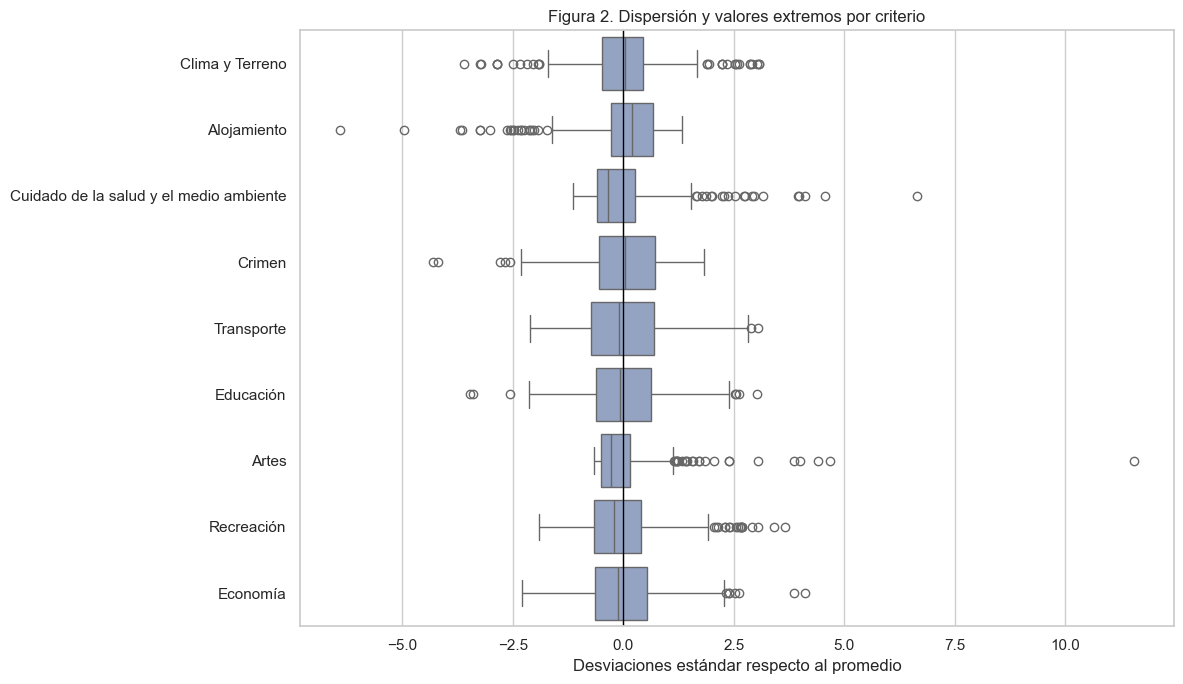

In [8]:
z_largo = (
    Z.assign(Ciudad=datos["Ciudad"])
    .melt(id_vars="Ciudad", var_name="Criterio", value_name="Puntaje_z")
)
plt.figure(figsize=(12, 7))
sns.boxplot(data=z_largo, x="Puntaje_z", y="Criterio", color="#8DA0CB", showfliers=True)
plt.axvline(0, color="black", linewidth=1)
plt.title("Figura 2. Dispersión y valores extremos por criterio")
plt.xlabel("Desviaciones estándar respecto al promedio")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Hallazgo: las ciudades extremas son parte de la historia

Los casos extremos no parecen errores de digitación; son ciudades con perfiles poco comunes. Se mantienen porque pueden ser candidatas reales. Más adelante se repetirá el ajuste sin ellas para comprobar si cambian la lista final.

## 4. Estandarización

Cada criterio orientado se centra y divide por su desviación estándar poblacional. Así una unidad representa una desviación estándar respecto al conjunto de 329 ciudades. Esta escala también permite describir fortalezas y debilidades con una métrica común.

In [9]:
escalador = StandardScaler()
X_std = escalador.fit_transform(X_orientado)
X_std = pd.DataFrame(X_std, columns=variables, index=datos.index)

verificacion = X_std.agg(["mean", lambda s: s.std(ddof=0)]).T
verificacion.columns = ["media", "desv_estándar_poblacional"]
display(verificacion)
assert np.allclose(X_std.mean(), 0, atol=1e-12)
assert np.allclose(X_std.std(ddof=0), 1, atol=1e-12)

,media,desv_estándar_poblacional
Clima y Terreno,0.000,1.000
Alojamiento,-0.000,1.000
Cuidado de la salud y el medio ambiente,-0.000,1.000
Crimen,-0.000,1.000
Transporte,-0.000,1.000
Educación,0.000,1.000
Artes,0.000,1.000
Recreación,-0.000,1.000
Economía,-0.000,1.000


## 5. PCA y número de componentes

Se ajustan los nueve componentes con SVD completa. La selección no aplica una regla mecánicamente: se contrastan Kaiser, sedimentación, varianza acumulada e interpretabilidad.

In [10]:
pca = PCA(svd_solver="full")
scores_total = pca.fit_transform(X_std)
proporcion = pca.explained_variance_ratio_
acumulada = proporcion.cumsum()
eigenvalues = pca.explained_variance_

tabla_varianza = pd.DataFrame({
    "componente": [f"CP{i}" for i in range(1, 10)],
    "eigenvalue": eigenvalues,
    "varianza_explicada": proporcion,
    "varianza_acumulada": acumulada,
})
n_kaiser = int((eigenvalues > 1).sum())
n_80 = int(np.argmax(acumulada >= 0.80) + 1)

display(tabla_varianza)
print("Kaiser (eigenvalue > 1):", n_kaiser, "componentes")
print("Mínimo para explicar al menos 80%:", n_80, "componentes")

,componente,eigenvalue,varianza_explicada,varianza_acumulada
0,CP1,3.419,0.379,0.379
1,CP2,1.218,0.135,0.514
2,CP3,1.145,0.127,0.640
3,CP4,0.924,0.102,0.743
4,CP5,0.756,0.084,0.826
5,CP6,0.632,0.070,0.897
6,CP7,0.495,0.055,0.951
7,CP8,0.319,0.035,0.987
8,CP9,0.121,0.013,1.000


Kaiser (eigenvalue > 1): 3 componentes
Mínimo para explicar al menos 80%: 5 componentes


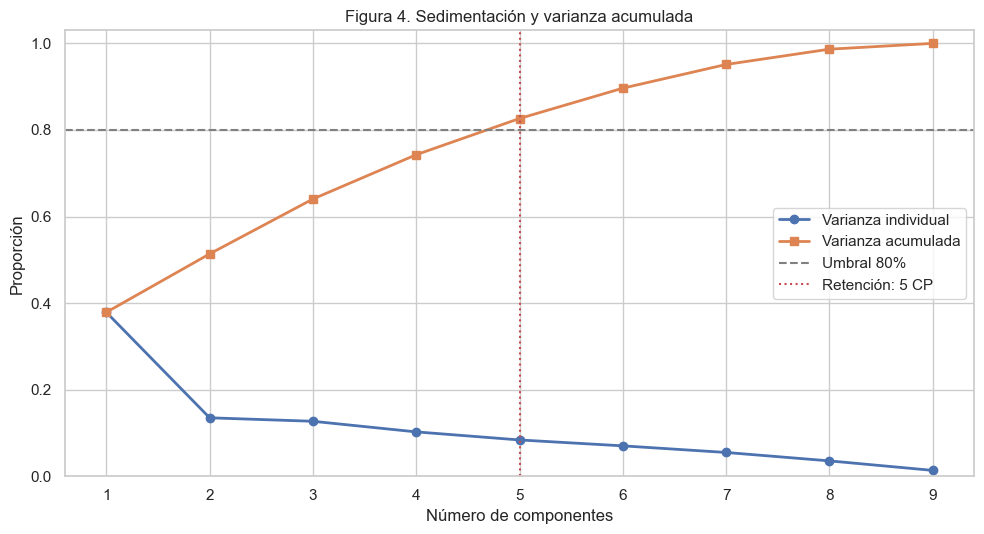

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))
x = np.arange(1, 10)
ax1.plot(x, proporcion, marker="o", linewidth=2, label="Varianza individual")
ax1.plot(x, acumulada, marker="s", linewidth=2, label="Varianza acumulada")
ax1.axhline(0.80, color="gray", linestyle="--", label="Umbral 80%")
ax1.axvline(n_80, color="#C44E52", linestyle=":", label=f"Retención: {n_80} CP")
ax1.set(xticks=x, xlabel="Número de componentes", ylabel="Proporción", ylim=(0, 1.03))
ax1.set_title("Figura 4. Sedimentación y varianza acumulada")
ax1.legend(loc="center right")
plt.tight_layout()
plt.show()

### Hallazgo: cinco componentes conservan una visión suficientemente amplia

Tres componentes resumen cerca del 64% de las diferencias, pero dejan por fuera señales útiles de vivienda, seguridad, recreación y transporte. Con cinco se conserva aproximadamente el 83%. Es un equilibrio razonable entre simplificar la información y no borrar contrastes importantes para una sede.

## 6. Cargas e interpretación

Las cargas siguientes son los coeficientes de las combinaciones lineales. El signo global de una CP es arbitrario; la interpretación depende de qué criterios aparecen juntos o contrapuestos, no de que el signo sea positivo en sí mismo.

,CP1,CP2,CP3,CP4,CP5
Clima y Terreno,0.206,-0.218,0.690,0.137,-0.369
Alojamiento,-0.357,0.251,-0.208,-0.512,-0.233
Cuidado de la salud y el medio ambiente,0.460,0.299,0.007,0.015,-0.103
Crimen,-0.281,0.355,0.185,0.539,0.524
Transporte,0.351,0.180,-0.146,-0.303,0.404
Educación,0.275,0.483,-0.230,0.335,-0.209
Artes,0.463,0.195,0.026,-0.101,-0.105
Recreación,0.328,-0.384,0.051,-0.190,0.530
Economía,0.135,-0.471,-0.607,0.422,-0.160


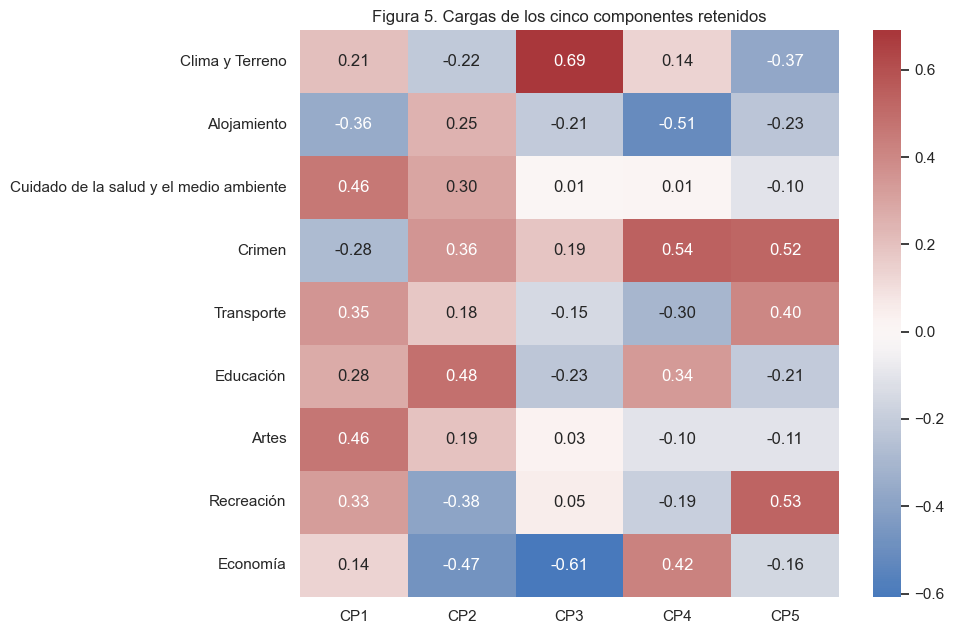

In [12]:
n_componentes = n_80
cargas = pd.DataFrame(
    pca.components_.T,
    index=variables,
    columns=[f"CP{i}" for i in range(1, 10)],
)
cargas_retenidas = cargas.iloc[:, :n_componentes]
display(cargas_retenidas.round(3))

plt.figure(figsize=(10, 6.5))
sns.heatmap(cargas_retenidas, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Figura 5. Cargas de los cinco componentes retenidos")
plt.tight_layout()
plt.show()

### ¿Qué historias cuentan los componentes?

- **CP1 - oferta urbana frente a costo y seguridad:** las ciudades con mucha salud, cultura, transporte y recreación tienden a pagar un precio en vivienda o seguridad.
- **CP2 - educación y seguridad frente a actividad económica/recreativa:** muestra otro tipo de equilibrio entre vida familiar y dinamismo urbano.
- **CP3 - clima frente a economía:** separa con claridad esos dos perfiles.
- **CP4 - seguridad y economía frente a vivienda y transporte:** recuerda que una ciudad no suele ganar en todo al mismo tiempo.
- **CP5 - recreación, seguridad y conexión:** recoge una dimensión de calidad de vida y movilidad.

Estos nombres son ayudas para leer los datos de 1985, no etiquetas definitivas sobre las ciudades.

In [13]:
scores = pd.DataFrame(scores_total[:, :n_componentes], columns=cargas_retenidas.columns)
scores.insert(0, "Ciudad", datos["Ciudad"])

extremos_componentes = []
for cp in cargas_retenidas.columns:
    altos = scores.nlargest(3, cp)[["Ciudad", cp]].assign(extremo="alto")
    bajos = scores.nsmallest(3, cp)[["Ciudad", cp]].assign(extremo="bajo")
    extremos_componentes.append(pd.concat([altos, bajos]).rename(columns={cp: "puntuación"}).assign(componente=cp))
extremos_componentes = pd.concat(extremos_componentes, ignore_index=True)
display(extremos_componentes[["componente", "extremo", "Ciudad", "puntuación"]])

,componente,extremo,Ciudad,puntuación
0,CP1,alto,"New-York,NY",12.445
1,CP1,alto,"San-Francisco,CA",7.403
2,CP1,alto,"Los-Angeles,Long-Beach,CA",7.257
3,CP1,bajo,"Gadsden,AL",-2.920
4,CP1,bajo,"Dothgan,AL",-2.793
5,CP1,bajo,"Pascagoula,MS",-2.738
6,CP2,alto,"Chicago,IL",3.092
7,CP2,alto,"Philadelphia,PA-NJ",3.078
8,CP2,alto,"Pittsburgh,PA",2.460
9,CP2,bajo,"Las-Vegas,NV",-3.344


## 7. Índice de atractivo y ranking

PCA describe la estructura, pero no decide qué le importa al comité. Como el caso no entrega preferencias cuantificadas, el escenario principal asigna **peso igual (1/9) a los nueve criterios ya orientados**. Es la regla neutral más transparente: no confunde varianza estadística con importancia empresarial.

Para usar PCA como insumo, se reconstruye cada ciudad con las cinco CP retenidas y se calcula el promedio de sus nueve criterios reconstruidos. Algebraicamente, si $T_5$ son las puntuaciones, $V_5$ las cargas y $w$ el vector de pesos, el índice es $T_5V_5w$. Así PCA filtra el 17.4% de variación de menor prioridad descriptiva, mientras $w$ hace explícita la preferencia de negocio. El resultado se estandariza y se ordena de mayor a menor.

In [14]:
pesos_iguales = np.repeat(1 / len(variables), len(variables))
coeficientes_cp = pca.components_[:n_componentes] @ pesos_iguales
indice_crudo = scores_total[:, :n_componentes] @ coeficientes_cp
indice_z = (indice_crudo - indice_crudo.mean()) / indice_crudo.std(ddof=0)

tabla_pesos = pd.DataFrame({"criterio": variables, "peso_empresarial": pesos_iguales})
tabla_coef_cp = pd.DataFrame({
    "componente": [f"CP{i}" for i in range(1, n_componentes + 1)],
    "coeficiente_en_índice": coeficientes_cp,
})
display(tabla_pesos)
display(tabla_coef_cp)

,criterio,peso_empresarial
0,Clima y Terreno,0.111
1,Alojamiento,0.111
2,Cuidado de la salud y el medio ambiente,0.111
3,Crimen,0.111
4,Transporte,0.111
5,Educación,0.111
6,Artes,0.111
7,Recreación,0.111
8,Economía,0.111


,componente,coeficiente_en_índice
0,CP1,0.176
1,CP2,0.077
2,CP3,-0.026
3,CP4,0.038
4,CP5,0.031


In [15]:
ranking = datos.copy()
ranking["Indice_atractivo_z"] = indice_z
ranking["Ranking"] = ranking["Indice_atractivo_z"].rank(method="min", ascending=False).astype(int)
ranking = ranking.sort_values(["Ranking", "Ciudad"]).reset_index(drop=True)

columnas_ranking = ["Ranking", "Ciudad", "Indice_atractivo_z"] + variables
print("Diez primeras ciudades")
display(ranking[columnas_ranking].head(10))
print("Diez últimas ciudades")
display(ranking[columnas_ranking].tail(10))

Diez primeras ciudades


,Ranking,Ciudad,Indice_atractivo_z,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
0,1,"New-York,NY",6.355,638,13358,7850,2498,8625,2984,56745,3579,5338
1,2,"Chicago,IL",4.083,514,10913,5766,1034,7742,3486,24846,2856,5205
2,3,"Washington,DC-MD-VA",3.759,631,13724,4361,1317,8236,3635,21701,1578,6072
3,4,"Boston,MA",3.674,623,11609,5301,1215,6801,3479,21042,3066,6363
4,5,"San-Francisco,CA",3.541,910,17158,3726,1619,8299,3371,14226,4600,6063
5,6,"Los-Angeles,Long-Beach,CA",3.284,885,13868,5153,1960,4345,3195,23567,3948,5316
6,7,"Philadelphia,PA-NJ",3.120,630,8310,5158,1059,5903,3781,17270,1979,5638
7,8,"Baltimore,MD",2.330,567,9148,3562,1730,7405,3471,9788,2925,5503
8,9,"Newark,NJ",2.295,601,14220,4106,1461,3514,3362,14224,1818,5690
9,10,"Pittsburgh,PA",2.018,586,8099,3413,687,5616,3544,11069,2145,5261


Diez últimas ciudades


,Ranking,Ciudad,Indice_atractivo_z,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
319,320,"Anderson,IN",-1.285,530,5704,580,878,2865,2469,430,838,3370
320,321,"Yuba-City,CA",-1.297,608,7875,212,1179,2768,2387,122,918,4694
321,322,"Pine-Bluff,AR",-1.385,463,5674,617,1169,1671,2554,373,793,4247
322,323,"Richland-Kinnewick-Pasco,WA",-1.387,664,8461,300,779,4714,1728,529,1204,5326
323,324,"Florence,AL",-1.398,546,5962,607,516,1454,2427,1021,994,4492
324,325,"Houma-Thibodaux,LA",-1.438,427,7094,583,400,1145,1995,725,2700,6662
325,326,"Anniston,AL",-1.450,560,5530,598,1125,3051,2189,268,1165,4730
326,327,"Dothgan,AL",-1.534,336,5708,593,930,2232,2230,117,714,5453
327,328,"Gadsden,AL",-1.605,526,5382,622,749,2174,2299,153,300,4220
328,329,"Pascagoula,MS",-1.916,584,6248,593,591,1750,1701,155,1956,4491


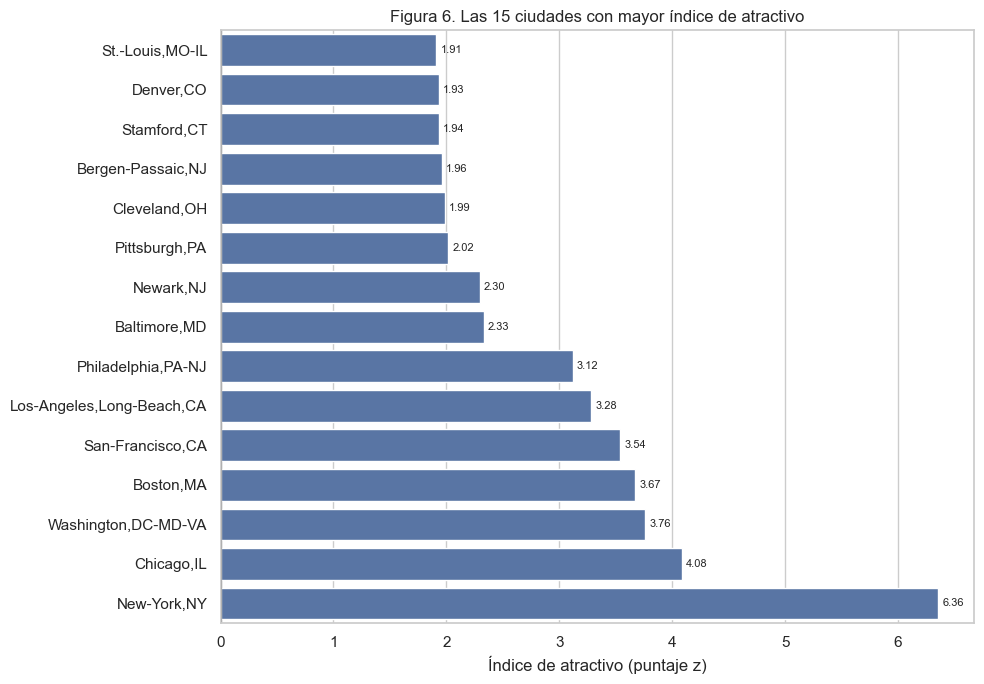

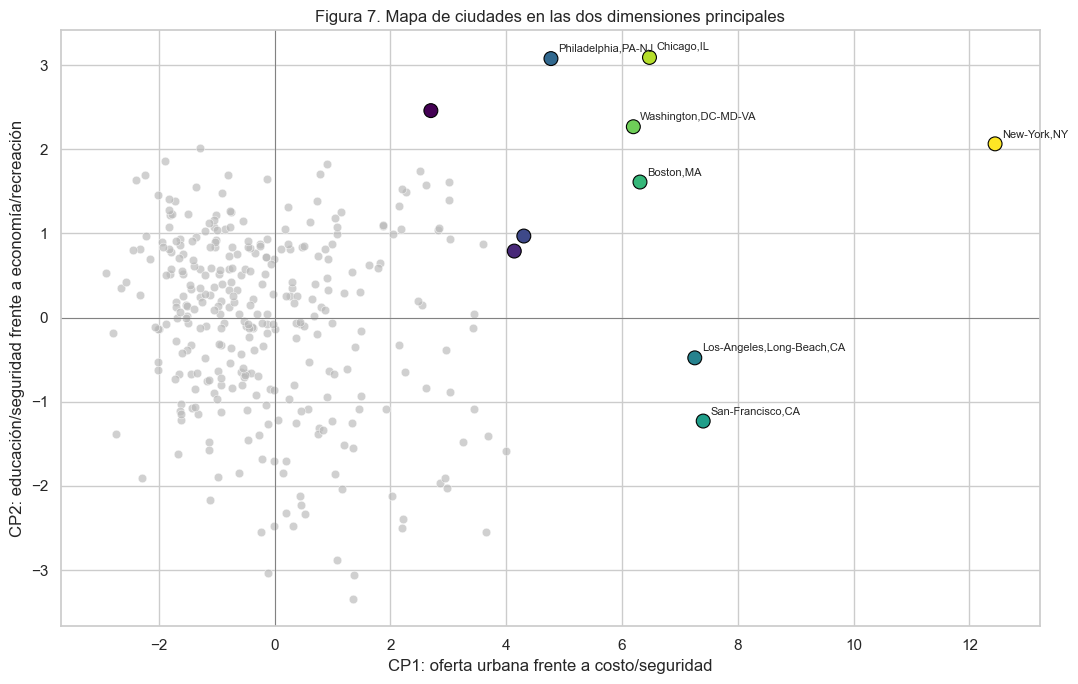

In [16]:
top15_grafico = ranking.head(15).sort_values("Indice_atractivo_z")
plt.figure(figsize=(10, 7))
ax = sns.barplot(data=top15_grafico, x="Indice_atractivo_z", y="Ciudad", color="#4C72B0")
ax.axvline(0, color="black", linewidth=0.8)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
plt.title("Figura 6. Las 15 ciudades con mayor índice de atractivo")
plt.xlabel("Índice de atractivo (puntaje z)")
plt.ylabel("")
plt.tight_layout()
plt.show()

mapa_pca = scores[["Ciudad", "CP1", "CP2"]].merge(
    ranking[["Ciudad", "Ranking"]], on="Ciudad", how="left"
)
plt.figure(figsize=(11, 7))
sns.scatterplot(data=mapa_pca, x="CP1", y="CP2", color="#B8B8B8", alpha=0.65, s=38)
destacadas = mapa_pca.nsmallest(10, "Ranking")
sns.scatterplot(
    data=destacadas, x="CP1", y="CP2", hue="Ranking", palette="viridis_r",
    s=100, edgecolor="black", legend=False
)
for _, fila in destacadas.head(7).iterrows():
    plt.annotate(fila["Ciudad"], (fila["CP1"], fila["CP2"]), xytext=(5, 5),
                 textcoords="offset points", fontsize=8)
plt.axhline(0, color="gray", linewidth=0.7)
plt.axvline(0, color="gray", linewidth=0.7)
plt.title("Figura 7. Mapa de ciudades en las dos dimensiones principales")
plt.xlabel("CP1: oferta urbana frente a costo/seguridad")
plt.ylabel("CP2: educación/seguridad frente a economía/recreación")
plt.tight_layout()
plt.show()

### Hallazgo: el ranking favorece ciudades completas, no ciudades perfectas

Las primeras posiciones corresponden a ciudades con una oferta urbana muy amplia. Sin embargo, sus buenos resultados en salud, cultura y transporte conviven con debilidades claras en vivienda y seguridad. El ranking muestra un balance; no afirma que la primera ciudad sea la mejor en cada criterio.

## 8. Sensibilidad y robustez

Se prueban cuatro decisiones frente al principal:

1. **Promedio directo:** no descartar el 17.4% de variación restante.
2. **PCA-Kaiser:** retener solo 3 CP.
3. **Prioridad talento/familias:** mayor peso a Salud, Educación y seguridad; peso intermedio a Alojamiento, Transporte y Economía.
4. **Ajuste sin atípicos:** entrenar el escalador y PCA sin las 81 ciudades marcadas por IQR y volver a puntuar las 329.

Las correlaciones de Spearman evalúan el orden completo; la coincidencia *top 10* evalúa la zona decisiva.

,Rank_Principal_PCA80,Rank_Promedio_directo,Rank_PCA_Kaiser,Rank_Prioridad_talento,Rank_Ajuste_sin_atípicos
Rank_Principal_PCA80,1.000,0.859,0.983,0.977,0.924
Rank_Promedio_directo,0.859,1.000,0.838,0.841,0.904
Rank_PCA_Kaiser,0.983,0.838,1.000,0.942,0.945
Rank_Prioridad_talento,0.977,0.841,0.942,1.000,0.879
Rank_Ajuste_sin_atípicos,0.924,0.904,0.945,0.879,1.000


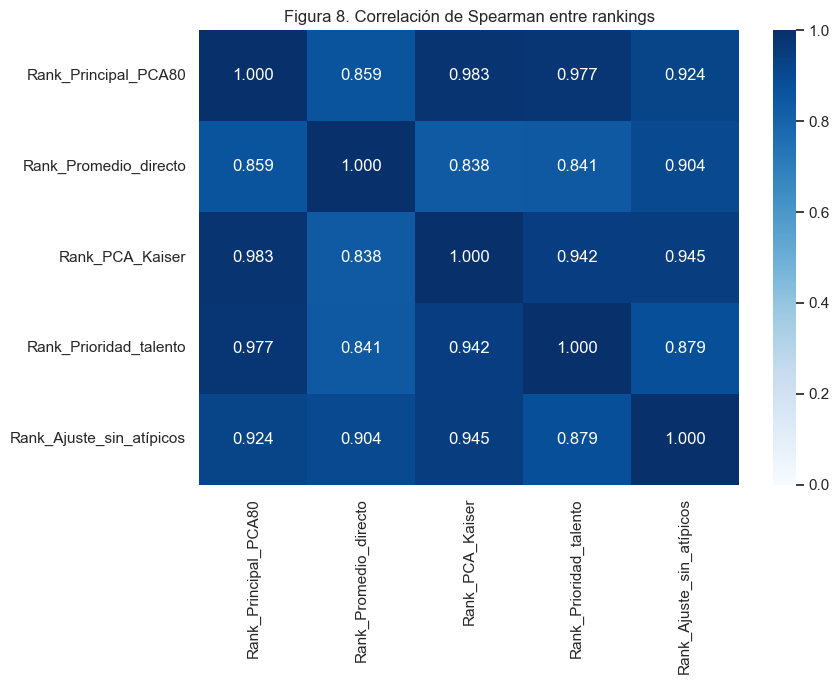

In [17]:
def estandarizar_vector(x):
    x = np.asarray(x)
    return (x - x.mean()) / x.std(ddof=0)

escenarios = pd.DataFrame({"Ciudad": datos["Ciudad"]})
escenarios["Principal_PCA80"] = estandarizar_vector(indice_crudo)
escenarios["Promedio_directo"] = estandarizar_vector(X_std.to_numpy() @ pesos_iguales)

coef_kaiser = pca.components_[:n_kaiser] @ pesos_iguales
escenarios["PCA_Kaiser"] = estandarizar_vector(scores_total[:, :n_kaiser] @ coef_kaiser)

pesos_talento = pd.Series(1.0, index=variables)
pesos_talento[["Cuidado de la salud y el medio ambiente", "Educación", "Crimen"]] = 1.5
pesos_talento[["Alojamiento", "Transporte", "Economía"]] = 1.2
pesos_talento = (pesos_talento / pesos_talento.sum()).to_numpy()
coef_talento = pca.components_[:n_componentes] @ pesos_talento
escenarios["Prioridad_talento"] = estandarizar_vector(scores_total[:, :n_componentes] @ coef_talento)

X_entrenamiento = X_orientado.loc[~es_atipica]
escalador_sin = StandardScaler().fit(X_entrenamiento)
Z_entrenamiento = escalador_sin.transform(X_entrenamiento)
pca_sin = PCA(svd_solver="full").fit(Z_entrenamiento)
n_80_sin = int(np.argmax(pca_sin.explained_variance_ratio_.cumsum() >= 0.80) + 1)
scores_sin = pca_sin.transform(escalador_sin.transform(X_orientado))
coef_sin = pca_sin.components_[:n_80_sin] @ pesos_iguales
escenarios["Ajuste_sin_atípicos"] = estandarizar_vector(scores_sin[:, :n_80_sin] @ coef_sin)

nombres_escenarios = [c for c in escenarios.columns if c != "Ciudad"]
for nombre in nombres_escenarios:
    escenarios[f"Rank_{nombre}"] = escenarios[nombre].rank(method="min", ascending=False)

columnas_rank = [f"Rank_{c}" for c in nombres_escenarios]
corr_rank = escenarios[columnas_rank].corr(method="spearman")
display(corr_rank)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_rank, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("Figura 8. Correlación de Spearman entre rankings")
plt.tight_layout()
plt.show()

In [18]:
top_principal = set(escenarios.nlargest(10, "Principal_PCA80")["Ciudad"])
coincidencias = []
for nombre in nombres_escenarios[1:]:
    top_alterno = set(escenarios.nlargest(10, nombre)["Ciudad"])
    coincidencias.append({
        "escenario": nombre,
        "coincidencias_top10": len(top_principal & top_alterno),
        "porcentaje": len(top_principal & top_alterno) / 10,
    })
coincidencias = pd.DataFrame(coincidencias)
display(coincidencias)

estabilidad = escenarios[["Ciudad"] + columnas_rank].copy()
estabilidad["Ranking_promedio"] = estabilidad[columnas_rank].mean(axis=1)
estabilidad["Desv_ranking"] = estabilidad[columnas_rank].std(axis=1)
estabilidad["Mejor_ranking"] = estabilidad[columnas_rank].min(axis=1)
estabilidad["Peor_ranking"] = estabilidad[columnas_rank].max(axis=1)
display(estabilidad.sort_values(["Ranking_promedio", "Desv_ranking"]).head(15))

,escenario,coincidencias_top10,porcentaje
0,Promedio_directo,8,0.800
1,PCA_Kaiser,9,0.900
2,Prioridad_talento,10,1.000
3,Ajuste_sin_atípicos,9,0.900


,Ciudad,Rank_Principal_PCA80,Rank_Promedio_directo,Rank_PCA_Kaiser,Rank_Prioridad_talento,Rank_Ajuste_sin_atípicos,Ranking_promedio,Desv_ranking,Mejor_ranking,Peor_ranking
212,"New-York,NY",1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000
64,"Chicago,IL",2.000,2.000,2.000,2.000,3.000,2.200,0.447,2.000,3.000
313,"Washington,DC-MD-VA",3.000,6.000,3.000,3.000,4.000,3.800,1.304,3.000,6.000
42,"Boston,MA",4.000,3.000,4.000,4.000,5.000,4.000,0.707,3.000,5.000
269,"San-Francisco,CA",5.000,5.000,6.000,6.000,2.000,4.800,1.643,2.000,6.000
233,"Philadelphia,PA-NJ",7.000,4.000,7.000,5.000,7.000,6.000,1.414,4.000,7.000
178,"Los-Angeles,Long-Beach,CA",6.000,7.000,5.000,7.000,6.000,6.200,0.837,5.000,7.000
25,"Baltimore,MD",8.000,14.000,8.000,10.000,8.000,9.600,2.608,8.000,14.000
236,"Pittsburgh,PA",10.000,10.000,12.000,9.000,9.000,10.000,1.225,9.000,12.000
261,"St.-Louis,MO-IL",15.000,13.000,11.000,14.000,10.000,12.600,2.074,10.000,15.000


### Hallazgo: la parte alta del ranking es estable

Aunque cambian la cantidad de componentes, los pesos y el tratamiento de casos extremos, los rankings se parecen bastante. Las cinco ciudades seleccionadas nunca caen más allá del sexto puesto. Esto da más confianza en la lista corta que en el orden exacto entre sus integrantes.

## 9. Cinco finalistas

La selección usa, en orden: menor ranking promedio en los cinco escenarios, menor dispersión y mejor ranking principal. Esta regla privilegia robustez y es previa a observar los nombres; no se sustituyen ciudades por juicio subjetivo posterior.

In [19]:
finalistas = (
    estabilidad
    .merge(ranking[["Ciudad", "Ranking", "Indice_atractivo_z"]], on="Ciudad", how="left")
    .sort_values(["Ranking_promedio", "Desv_ranking", "Ranking", "Ciudad"])
    .head(5)
    .reset_index(drop=True)
)
finalistas.insert(0, "Orden_recomendación", range(1, 6))
display(finalistas)

ciudades_finalistas = finalistas["Ciudad"].tolist()
assert ciudades_finalistas == ["New-York,NY", "Chicago,IL", "Washington,DC-MD-VA", "Boston,MA", "San-Francisco,CA"]

,Orden_recomendación,Ciudad,Rank_Principal_PCA80,Rank_Promedio_directo,Rank_PCA_Kaiser,Rank_Prioridad_talento,Rank_Ajuste_sin_atípicos,Ranking_promedio,Desv_ranking,Mejor_ranking,Peor_ranking,Ranking,Indice_atractivo_z
0,1,"New-York,NY",1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1,6.355
1,2,"Chicago,IL",2.000,2.000,2.000,2.000,3.000,2.200,0.447,2.000,3.000,2,4.083
2,3,"Washington,DC-MD-VA",3.000,6.000,3.000,3.000,4.000,3.800,1.304,3.000,6.000,3,3.759
3,4,"Boston,MA",4.000,3.000,4.000,4.000,5.000,4.000,0.707,3.000,5.000,4,3.674
4,5,"San-Francisco,CA",5.000,5.000,6.000,6.000,2.000,4.800,1.643,2.000,6.000,5,3.541


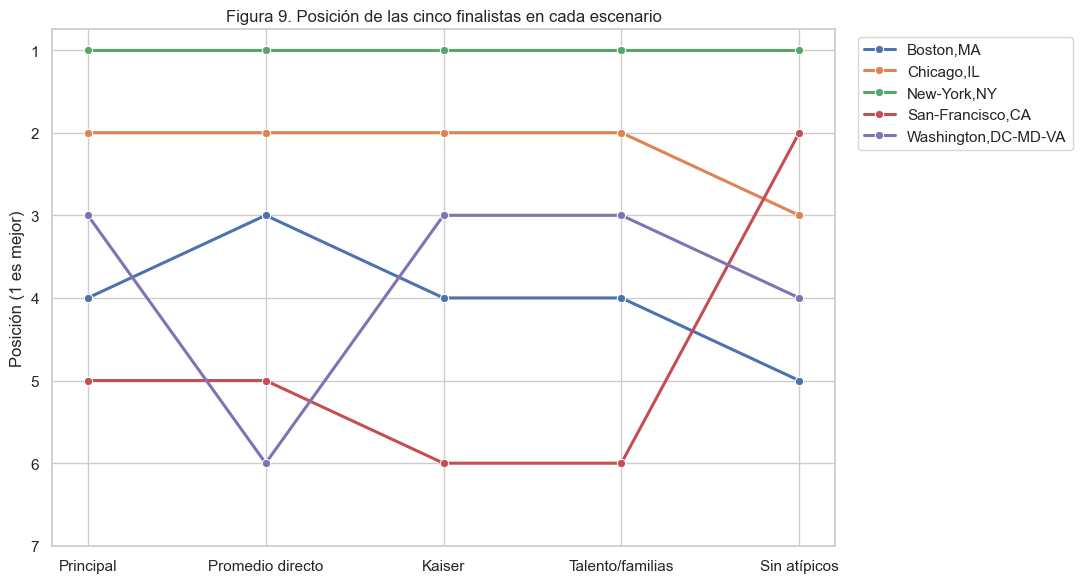

In [20]:
orden_escenarios = [f"Rank_{c}" for c in nombres_escenarios]
etiquetas_escenarios = {
    "Rank_Principal_PCA80": "Principal",
    "Rank_Promedio_directo": "Promedio directo",
    "Rank_PCA_Kaiser": "Kaiser",
    "Rank_Prioridad_talento": "Talento/familias",
    "Rank_Ajuste_sin_atípicos": "Sin atípicos",
}
estabilidad_finalistas = (
    estabilidad[estabilidad["Ciudad"].isin(ciudades_finalistas)]
    .melt(id_vars="Ciudad", value_vars=orden_escenarios,
          var_name="Escenario", value_name="Posición")
)
estabilidad_finalistas["Escenario"] = estabilidad_finalistas["Escenario"].map(etiquetas_escenarios)
estabilidad_finalistas["Escenario"] = pd.Categorical(
    estabilidad_finalistas["Escenario"], categories=list(etiquetas_escenarios.values()), ordered=True
)
plt.figure(figsize=(11, 6))
sns.lineplot(data=estabilidad_finalistas, x="Escenario", y="Posición", hue="Ciudad",
             marker="o", linewidth=2.2)
plt.gca().invert_yaxis()
plt.yticks(range(1, 8))
plt.title("Figura 9. Posición de las cinco finalistas en cada escenario")
plt.xlabel("")
plt.ylabel("Posición (1 es mejor)")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

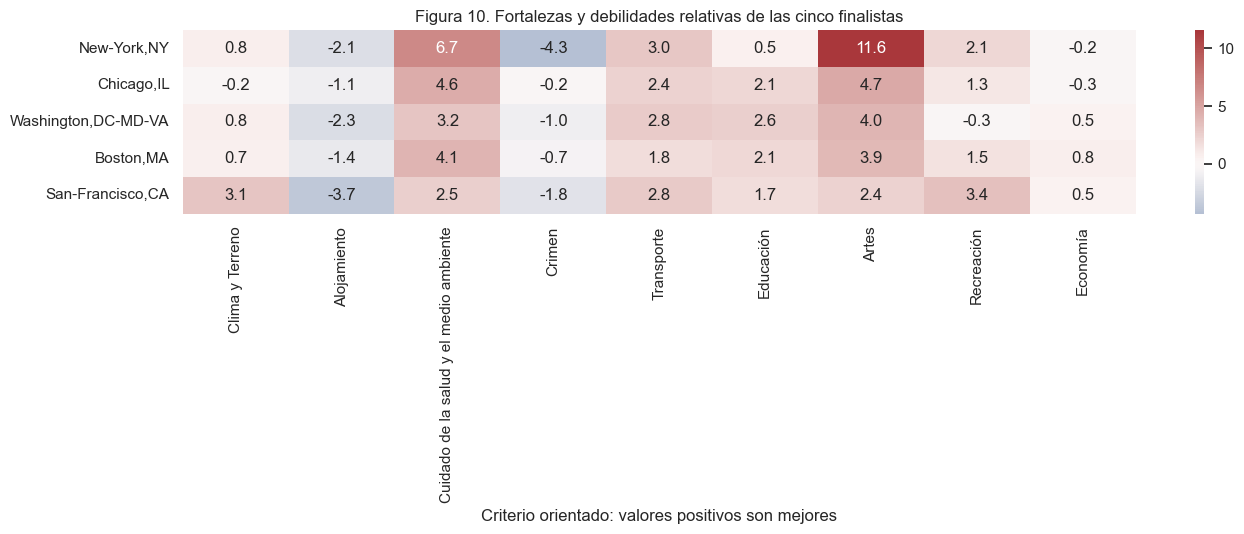

,Ciudad,Ranking_principal,Ranking_promedio,Peor_ranking,Fortalezas_relativas,Debilidades_relativas
0,"New-York,NY",1,1.000,1,Artes (11.56 z); Cuidado de la salud y el medi...,Alojamiento (-2.10 z); Crimen (-4.31 z)
1,"Chicago,IL",2,2.200,3,Artes (4.68 z); Cuidado de la salud y el medio...,Economía (-0.30 z); Alojamiento (-1.08 z)
2,"Washington,DC-MD-VA",3,3.800,6,Artes (4.00 z); Cuidado de la salud y el medio...,Crimen (-1.00 z); Alojamiento (-2.26 z)
3,"Boston,MA",4,4.000,5,Cuidado de la salud y el medio ambiente (4.11 ...,Crimen (-0.71 z); Alojamiento (-1.37 z)
4,"San-Francisco,CA",5,4.800,6,Recreación (3.41 z); Clima y Terreno (3.08 z);...,Crimen (-1.84 z); Alojamiento (-3.70 z)


In [21]:
perfiles = X_std.copy()
perfiles.insert(0, "Ciudad", datos["Ciudad"])
perfil_finalistas = perfiles.set_index("Ciudad").loc[ciudades_finalistas]

plt.figure(figsize=(14, 5.5))
sns.heatmap(perfil_finalistas, annot=True, fmt=".1f", cmap="vlag", center=0)
plt.title("Figura 10. Fortalezas y debilidades relativas de las cinco finalistas")
plt.xlabel("Criterio orientado: valores positivos son mejores")
plt.ylabel("")
plt.tight_layout()
plt.show()

resumen_finalistas = []
for ciudad in ciudades_finalistas:
    perfil = perfil_finalistas.loc[ciudad].sort_values(ascending=False)
    info = finalistas.loc[finalistas["Ciudad"] == ciudad].iloc[0]
    resumen_finalistas.append({
        "Ciudad": ciudad,
        "Ranking_principal": int(info["Ranking"]),
        "Ranking_promedio": info["Ranking_promedio"],
        "Peor_ranking": int(info["Peor_ranking"]),
        "Fortalezas_relativas": "; ".join(f"{v} ({perfil[v]:.2f} z)" for v in perfil.head(3).index),
        "Debilidades_relativas": "; ".join(f"{v} ({perfil[v]:.2f} z)" for v in perfil.tail(2).index),
    })
resumen_finalistas = pd.DataFrame(resumen_finalistas)
display(resumen_finalistas)

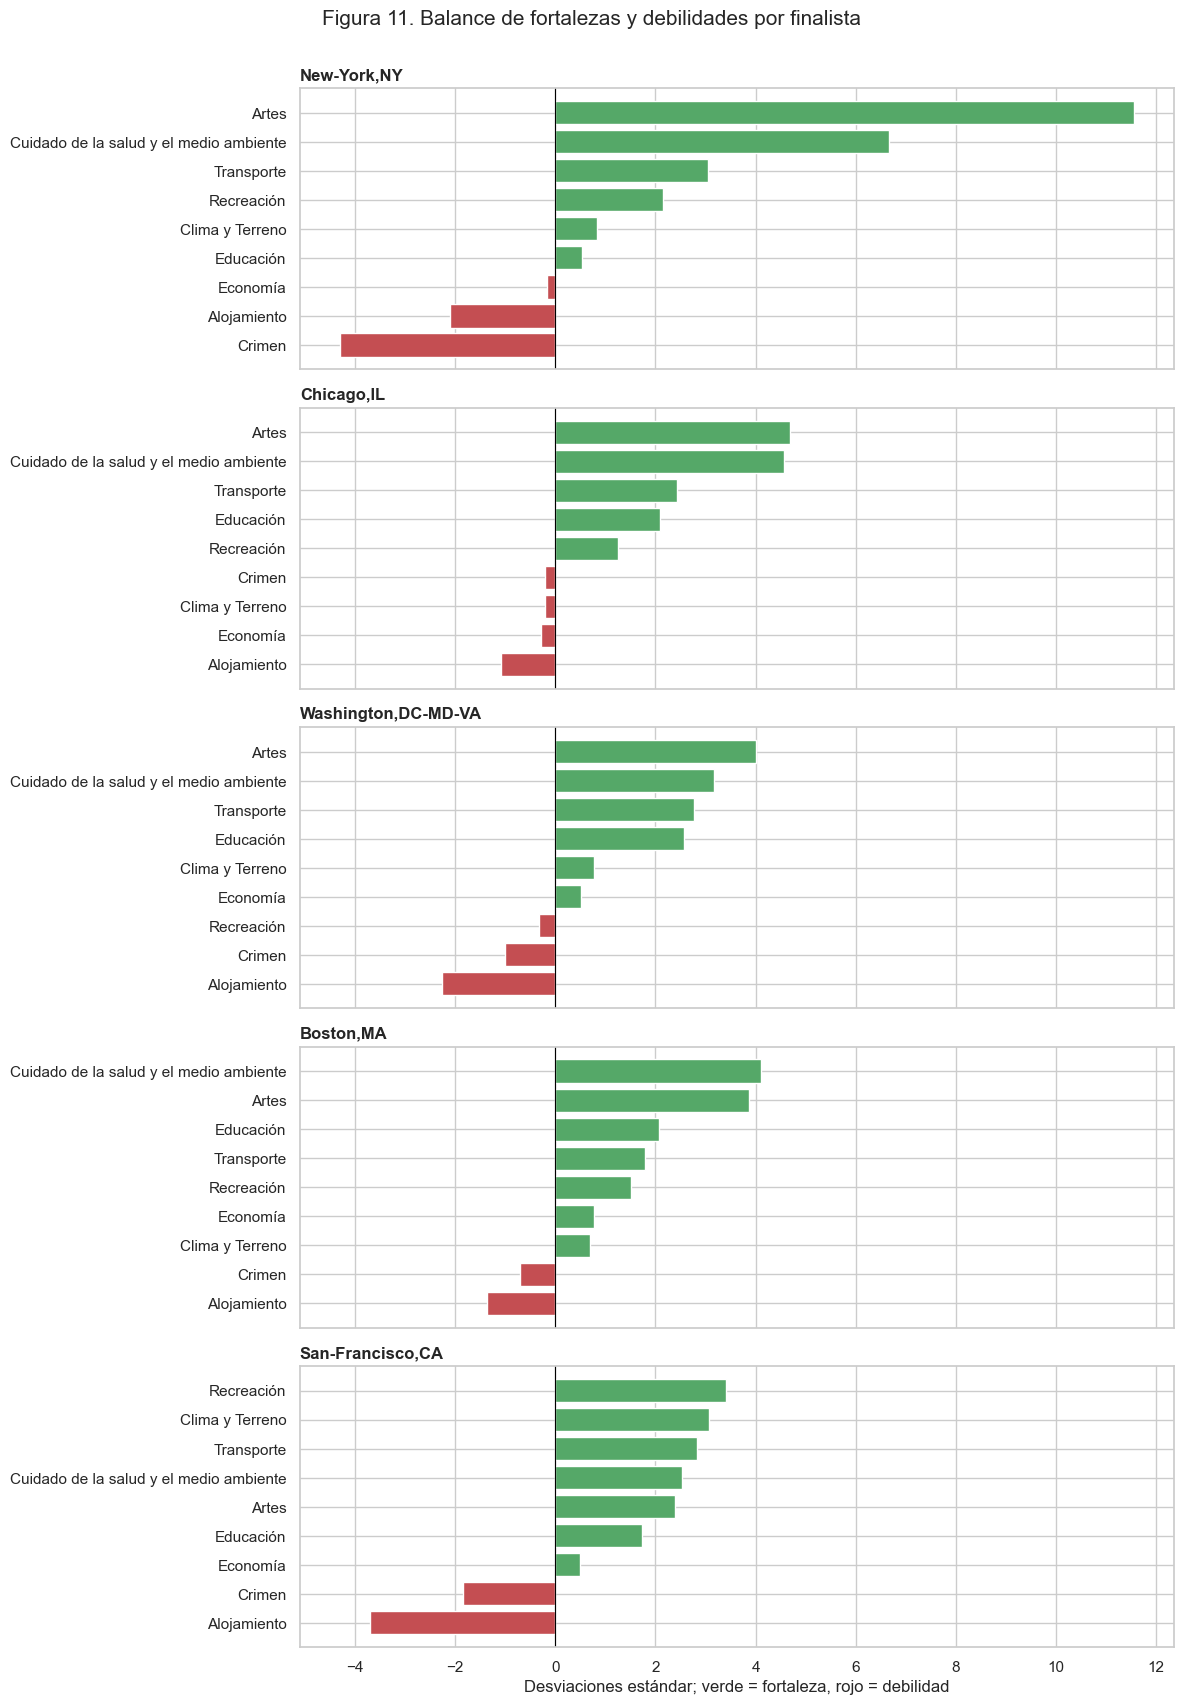

In [22]:
fig, axes = plt.subplots(len(ciudades_finalistas), 1, figsize=(12, 17), sharex=True)
for ax, ciudad in zip(axes, ciudades_finalistas):
    perfil = perfil_finalistas.loc[ciudad].sort_values()
    colores = ["#C44E52" if valor < 0 else "#55A868" for valor in perfil]
    ax.barh(perfil.index, perfil.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(ciudad, loc="left", fontweight="bold")
    ax.set_ylabel("")
axes[-1].set_xlabel("Desviaciones estándar; verde = fortaleza, rojo = debilidad")
fig.suptitle("Figura 11. Balance de fortalezas y debilidades por finalista", fontsize=15, y=1.002)
plt.tight_layout()
plt.show()

### ¿Qué gana y qué arriesga la empresa con cada finalista?

- **New York:** oferta excepcional de artes, salud y transporte. El costo de vivienda y la seguridad son alertas serias; estar de primera no significa ser una opción sin riesgo.
- **Chicago:** combina cultura, salud, transporte y educación. Sus puntos débiles están en vivienda y economía.
- **Washington DC-MD-VA:** sobresale en cultura, salud, transporte y educación, pero pierde atractivo por vivienda y crimen.
- **Boston:** tiene el perfil más equilibrado entre salud, cultura, educación, transporte y recreación; vivienda y crimen siguen bajo el promedio.
- **San Francisco:** destaca en recreación, clima y transporte. Su principal riesgo es la vivienda, acompañado por un resultado débil en crimen.

La lista favorece capacidad urbana y atracción de talento, pero concentra lugares costosos. La siguiente fase debe comprobar si esas ventajas todavía compensan sus costos actuales.

## 10. Limitaciones y decisión solicitada

### Limitaciones

- Los datos son de **1985**; no permiten recomendar una sede actual sin actualización.
- Los nueve puntajes agregados no informan definiciones, error de medición ni incertidumbre.
- No se incluyen salarios, disponibilidad de talento, alquiler de oficinas, impuestos, incentivos, conectividad digital, capacidad de expansión ni aceptación de traslado.
- El peso igual es neutral y auditable, pero no reemplaza preferencias explícitas del comité.
- PCA es lineal, sensible a la matriz de correlación y resume variación; no estima causalidad ni retorno financiero.
- Varias áreas corresponden a conglomerados metropolitanos, no necesariamente a límites administrativos comparables.

### Información para *due diligence*

Actualizar seguridad, vivienda y oficinas; disponibilidad/costo de talento; conectividad aérea, vial y digital; impuestos e incentivos; riesgos climáticos; capacidad de expansión; servicios para familias; y disposición real de empleados a trasladarse. Incluir una ciudad alternativa de alta asequibilidad como contraste comercial.

### Decisión solicitada

Autorizar estudios actuales, visitas y modelación financiera para las cinco finalistas, sin aprobar aún una sede definitiva. El comité debe además validar o modificar los pesos del índice antes de la decisión final.

## 11. Exportación para trazabilidad

Se guardan las tablas que pueden alimentar una presentación. Cualquier cifra presentada debe provenir de estos archivos o de una salida visible del cuaderno.

In [23]:
ranking.to_csv(RUTA_RESULTADOS / "ranking_completo_329_ciudades.csv", index=False)
resumen_finalistas.to_csv(RUTA_RESULTADOS / "cinco_ciudades_finalistas.csv", index=False)
tabla_varianza.to_csv(RUTA_RESULTADOS / "varianza_explicada_pca.csv", index=False)
cargas_retenidas.to_csv(RUTA_RESULTADOS / "cargas_componentes_retenidos.csv")
escenarios.to_csv(RUTA_RESULTADOS / "sensibilidad_rankings.csv", index=False)
perfil_finalistas.to_csv(RUTA_RESULTADOS / "perfiles_finalistas_z.csv")
correlaciones_fuertes.sort_values("abs_correlación", ascending=False).to_csv(
    RUTA_RESULTADOS / "correlaciones_criterios.csv", index=False
)

archivos = sorted(p.name for p in RUTA_RESULTADOS.glob("*.csv"))
print("Archivos generados:")
for archivo in archivos:
    print(" -", archivo)
assert len(archivos) == 7
print("\nValidación final: cuaderno ejecutado de principio a fin sin errores.")

Archivos generados:
 - cargas_componentes_retenidos.csv
 - cinco_ciudades_finalistas.csv
 - correlaciones_criterios.csv
 - perfiles_finalistas_z.csv
 - ranking_completo_329_ciudades.csv
 - sensibilidad_rankings.csv
 - varianza_explicada_pca.csv

Validación final: cuaderno ejecutado de principio a fin sin errores.
